# Factors That Change Normal Distribution

## Overview

The normal distribution is completely defined by **two parameters**:
- **μ (mean)** – changes the center/location
- **σ (standard deviation)** – changes the spread/shape

In AI/ML, understanding these factors helps with feature engineering, data normalization, and model interpretation.

## Factor 1: Changing the Mean (μ) – Location Shift

### What happens?
- The entire curve **shifts left or right** along the x-axis
- Shape remains exactly the same (same standard deviation)
- Peak moves to the new mean value

### Visual:
```
        μ=-2     μ=0      μ=2
         ↓        ↓        ↓
    ╭───╮         ╭───╮         ╭───╮
   ╱     ╲       ╱     ╲       ╱     ╲
  ╱       ╲     ╱       ╲     ╱       ╲
─┴───┴───┴───┴───┴───┴───┴───┴───┴───┴─
-4  -2   0    2    4    6
```

### Mathematical Effect:
If X ~ N(μ, σ²), then adding constant c: **X + c ~ N(μ + c, σ²)**

### Example:
- Distribution of heights (cm): μ = 170, σ = 10
- Add 5cm shoes: New distribution μ = 175, σ = 10

### In AI/ML:
- **Feature centering** – shifting data to have zero mean
- **Bias terms** in neural networks shift activation distributions
- **Transfer learning** – domain adaptation often requires mean shifts

## Factor 2: Changing the Standard Deviation (σ) – Spread Change

### What happens?
- Curve becomes **wider or narrower**
- **Small σ** → tall, skinny curve (low variance, data concentrated)
- **Large σ** → short, flat curve (high variance, data spread out)
- Total area under curve remains = 1

### Visual:
```
        σ=0.5 (tall, narrow)
           ╭─╮
          ╱   ╲
    σ=1  ╱     ╲
       ╱         ╲
    ╱             ╲
   ╱    σ=2 (flat) ╲
  ╱                 ╲
─┴───┴───┴───┴───┴───┴─
```

### Mathematical Effect:
If X ~ N(μ, σ²), then multiplying by constant c: **cX ~ N(cμ, c²σ²)**

### Example:
- Test scores: μ = 70, σ = 10 (moderate spread)
- Multiply by 2: μ = 140, σ = 20 (spread doubles)

### In AI/ML:
- **Feature scaling** – reducing variance for better convergence
- **Regularization** – controls weight variance (L1/L2)
- **Batch Normalization** – actively controls σ during training

## Combined Effects: Mean + Standard Deviation Changes

### Comparison Table:

| Change | Effect on Curve | Effect on Data | ML Application |
|--------|----------------|----------------|----------------|
| **Increase μ** | Shifts right | Larger values | Adding bias term |
| **Decrease μ** | Shifts left | Smaller values | Centering data |
| **Increase σ** | Wider, shorter | More spread | High variance features |
| **Decrease σ** | Narrower, taller | Less spread | Low variance features |

### Visual (all combinations):
```
              Original (μ=0, σ=1)
                    ╭─╮
                   ╱   ╲
    μ=2, σ=1      ╱     ╲       μ=0, σ=2
       ╭─╮      ╱       ╲      ╭─────╮
      ╱   ╲    ╱         ╲    ╱       ╲
     ╱     ╲  ╱           ╲  ╱         ╲
    ╱       ╲╱             ╲╱           ╲
───┴───┴───┴───┴───┴───┴───┴───┴───┴───┴──
-2   0    2    4    6    8
```

## Factor 3: Sample Size (n) – Distribution of Sample Means

### Central Limit Theorem Effect:
As sample size increases:
- Distribution of **sample means** becomes more normal
- Standard error decreases: **σₓ̄ = σ / √n**

### Visual:
```
n=5 (wide)     n=30 (medium)    n=100 (narrow)
   ╭───╮           ╭─╮              ╭╮
  ╱     ╲         ╱   ╲            ╱  ╲
 ╱       ╲       ╱     ╲          ╱    ╲
╱         ╲     ╱       ╲        ╱      ╲
─┴───┴───┴─   ─┴───┴───┴─   ──┴───┴───┴──
```

### Formula:
- **Standard Error (SE)** = σ / √n
- As n ↑ → SE ↓ → distribution narrower

### In AI/ML:
- **Bootstrap aggregating** (Bagging) – multiple samples reduce variance
- **Confidence intervals** – larger n gives tighter bounds
- **Training set size** – more data → more reliable statistics

## Factor 4: Linear Transformations

### General Formula:
If X ~ N(μ, σ²), then **Y = aX + b** ~ **N(aμ + b, a²σ²)**

| Transformation | Effect on Mean | Effect on Variance | Example |
|---------------|----------------|--------------------|---------|
| **Add constant (b)** | μ → μ + b | σ² unchanged | Temperature: °C → °F? (Actually °F = 1.8×°C + 32) |
| **Multiply by constant (a)** | μ → aμ | σ² → a²σ² | Scaling features |
| **Standardization** | μ → 0 | σ² → 1 | Z = (X - μ)/σ |

### Standardization (Z-score):
```
Z = (X - μ) / σ

Result: Z ~ N(0, 1)  [Standard Normal Distribution]
```

### In AI/ML:
- **Feature scaling** – all features on same scale
- **PCA** – requires standardized data
- **SVM, KNN, Neural Networks** – sensitive to feature scales

## Factor 5: Non-Linear Transformations (Normalizing Non-Normal Data)

### When data is NOT normal, apply transformations:

| Transformation | Formula | Best For | Effect |
|---------------|---------|----------|--------|
| **Log** | log(X) | Right-skewed data | Pulls in right tail |
| **Square Root** | √X | Count data | Reduces skewness |
| **Box-Cox** | (X^λ - 1)/λ | General case | Optimally normalizes |
| **Yeo-Johnson** | Similar but handles negatives | Data with zeros/negatives | Robust normalization |

### Visual Example (Log Transform):
```
Original (Right-Skewed)    After Log Transform (Normal)
      ╭╮                         ╭─╮
     ╱ ╲                       ╱   ╲
    ╱   ╲                     ╱     ╲
   ╱     ╲                   ╱       ╲
  ╱       ╲                 ╱         ╲
─┴───┴───┴─               ─┴───┴───┴───┴─
```

### In AI/ML:
- **Log-normal distributions** – common in financial data, click-through rates
- **Gaussian assumptions** – many models work better with normal data
- **Linear Regression** – normality of residuals required

## Complete Summary: Factors Affecting Normal Distribution

```
                    NORMAL DISTRIBUTION
                            │
            ┌───────────────┼───────────────┐
            │               │               │
        MEAN (μ)        STD DEV (σ)     SAMPLE SIZE (n)
            │               │               │
       Changes          Changes          Changes
       LOCATION          SPREAD          SE = σ/√n
            │               │               │
            └───────────────┼───────────────┘
                            │
                   LINEAR TRANSFORMATIONS
                    Y = aX + b → N(aμ+b, a²σ²)
                            │
                   NON-LINEAR TRANSFORMATIONS
                    Log, √X, Box-Cox, Yeo-Johnson
```

### Quick Reference Card:

| Factor | What Changes | ML Impact |
|--------|--------------|-----------|
| ↑ μ | Center → right | Add bias |
| ↓ μ | Center → left | Subtract bias |
| ↑ σ | Wider, shorter | More uncertainty |
| ↓ σ | Narrower, taller | Less uncertainty |
| ↑ n (CLT) | Narrower (SE↓) | Better estimates |
| Standardization | μ=0, σ=1 | Feature scaling |
| Log transform | Normalizes skew | Gaussian assumptions |

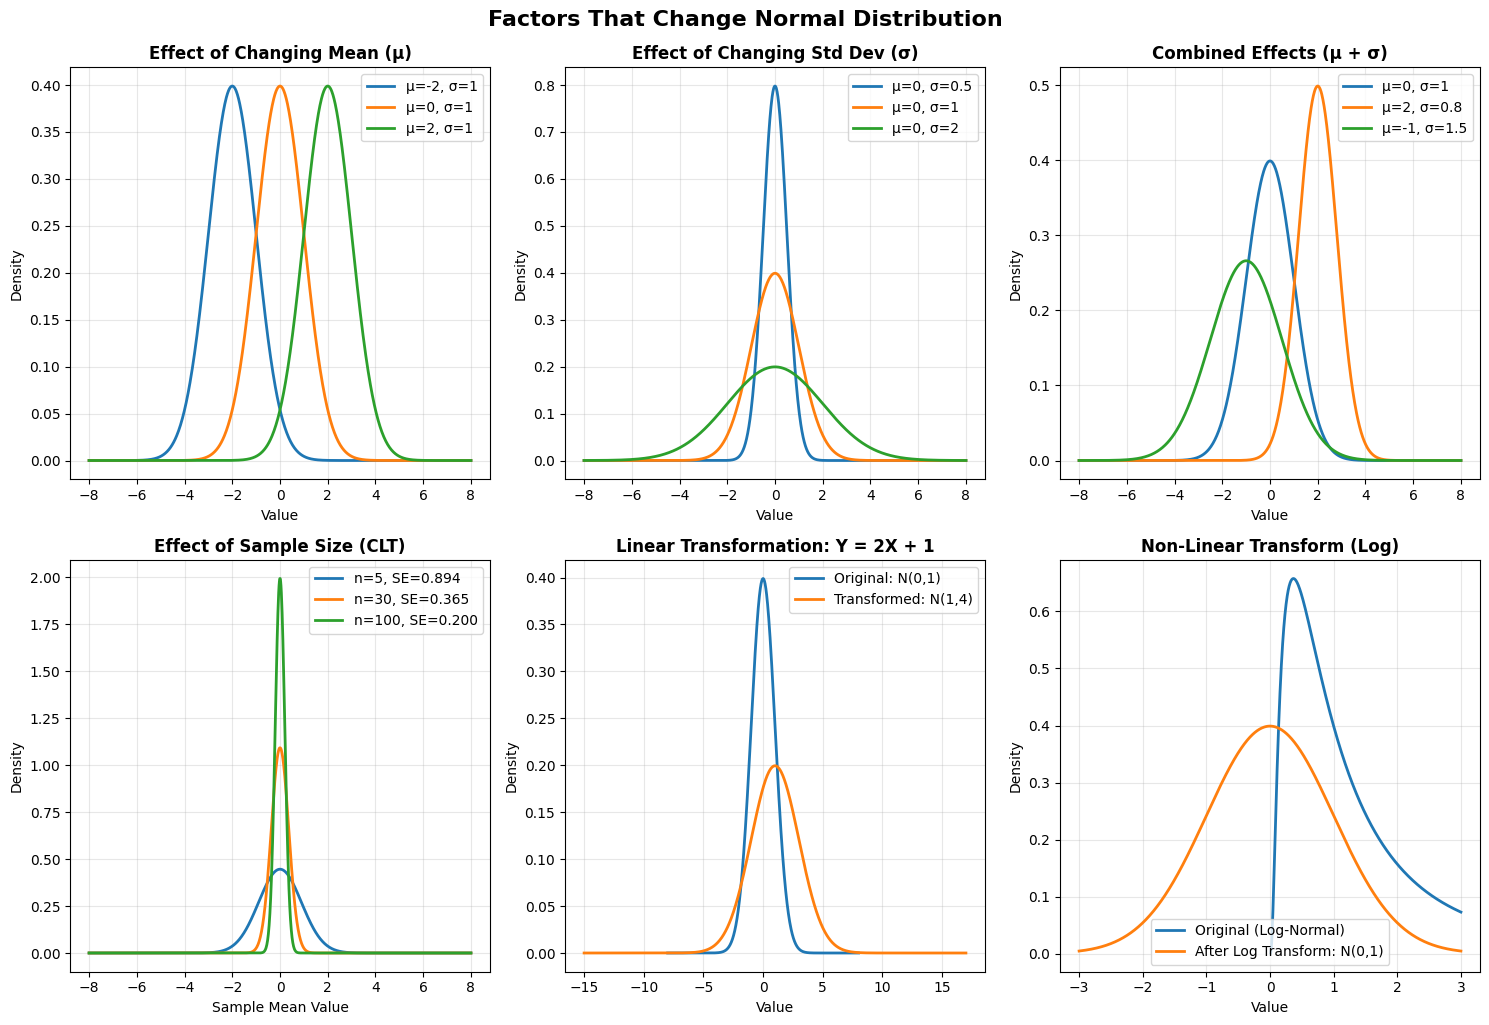

KEY STATISTICAL FACTS:
1. Adding constant c: N(μ, σ²) → N(μ+c, σ²)
2. Multiplying by a: N(μ, σ²) → N(aμ, a²σ²)
3. Standardization: Z = (X-μ)/σ → N(0,1)
4. Standard Error: SE = σ/√n → decreases with sample size
5. 68-95-99.7 rule applies ONLY after normalization


In [1]:
# Python Code: Visualizing Factors That Change Normal Distribution

import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

# Create figure with subplots
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
x = np.linspace(-8, 8, 1000)

# 1. Effect of Changing Mean
ax = axes[0, 0]
for mu in [-2, 0, 2]:
    ax.plot(x, norm.pdf(x, mu, 1), label=f'μ={mu}, σ=1', linewidth=2)
ax.set_title('Effect of Changing Mean (μ)', fontsize=12, fontweight='bold')
ax.set_xlabel('Value')
ax.set_ylabel('Density')
ax.legend()
ax.grid(alpha=0.3)

# 2. Effect of Changing Standard Deviation
ax = axes[0, 1]
for sigma in [0.5, 1, 2]:
    ax.plot(x, norm.pdf(x, 0, sigma), label=f'μ=0, σ={sigma}', linewidth=2)
ax.set_title('Effect of Changing Std Dev (σ)', fontsize=12, fontweight='bold')
ax.set_xlabel('Value')
ax.set_ylabel('Density')
ax.legend()
ax.grid(alpha=0.3)

# 3. Combined Effect (Different μ and σ)
ax = axes[0, 2]
params = [(0, 1), (2, 0.8), (-1, 1.5)]
for mu, sigma in params:
    ax.plot(x, norm.pdf(x, mu, sigma), label=f'μ={mu}, σ={sigma}', linewidth=2)
ax.set_title('Combined Effects (μ + σ)', fontsize=12, fontweight='bold')
ax.set_xlabel('Value')
ax.set_ylabel('Density')
ax.legend()
ax.grid(alpha=0.3)

# 4. Effect of Sample Size (Central Limit Theorem)
ax = axes[1, 0]
sample_sizes = [5, 30, 100]
original_sigma = 2
for n in sample_sizes:
    se = original_sigma / np.sqrt(n)
    ax.plot(x, norm.pdf(x, 0, se), label=f'n={n}, SE={se:.3f}', linewidth=2)
ax.set_title('Effect of Sample Size (CLT)', fontsize=12, fontweight='bold')
ax.set_xlabel('Sample Mean Value')
ax.set_ylabel('Density')
ax.legend()
ax.grid(alpha=0.3)

# 5. Linear Transformation (Scaling)
ax = axes[1, 1]
ax.plot(x, norm.pdf(x, 0, 1), label='Original: N(0,1)', linewidth=2)
# Apply Y = 2X + 1
x_transformed = 2*x + 1
ax.plot(x_transformed, norm.pdf(x, 0, 1)/2, label='Transformed: N(1,4)', linewidth=2)
ax.set_title('Linear Transformation: Y = 2X + 1', fontsize=12, fontweight='bold')
ax.set_xlabel('Value')
ax.set_ylabel('Density')
ax.legend()
ax.grid(alpha=0.3)

# 6. Non-Linear Transformations (Normalizing Skewed Data)
ax = axes[1, 2]
# Generate log-normal data
x_lognorm = np.linspace(0.01, 3, 1000)
log_normal_pdf = (1/(x_lognorm * 1 * np.sqrt(2*np.pi))) * np.exp(-(np.log(x_lognorm))**2 / (2*1**2))
ax.plot(x_lognorm, log_normal_pdf, label='Original (Log-Normal)', linewidth=2)
# After log transform (should be normal)
x_log = np.linspace(-3, 3, 1000)
ax.plot(x_log, norm.pdf(x_log, 0, 1), label='After Log Transform: N(0,1)', linewidth=2)
ax.set_title('Non-Linear Transform (Log)', fontsize=12, fontweight='bold')
ax.set_xlabel('Value')
ax.set_ylabel('Density')
ax.legend()
ax.grid(alpha=0.3)

plt.tight_layout()
plt.suptitle('Factors That Change Normal Distribution', fontsize=16, fontweight='bold', y=1.02)
plt.show()

# Bonus: Print statistical facts
print("=" * 60)
print("KEY STATISTICAL FACTS:")
print("=" * 60)
print(f"1. Adding constant c: N(μ, σ²) → N(μ+c, σ²)")
print(f"2. Multiplying by a: N(μ, σ²) → N(aμ, a²σ²)")
print(f"3. Standardization: Z = (X-μ)/σ → N(0,1)")
print(f"4. Standard Error: SE = σ/√n → decreases with sample size")
print(f"5. 68-95-99.7 rule applies ONLY after normalization")